In [35]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
import random
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from keras.callbacks import EarlyStopping

In [36]:
# Load dataset
df = pd.read_csv("Awake_Data.csv", header=0)

df

,5,10,15,20,25,30,35,40
0,0.138161,0.066419,0.088474,-0.211050,-0.263519,0.019489,-0.032790,0.332438
1,-0.032220,0.055066,0.314811,-0.484039,-0.314018,0.300224,0.521628,-0.068489
2,0.489065,0.093884,0.069215,0.120450,-0.104660,0.085914,0.221154,0.507176
3,0.265273,0.182474,0.075563,0.277022,-0.072290,-0.164319,0.135967,-0.074133
4,0.201336,0.083792,0.027693,-0.143447,0.112110,0.252779,0.238875,0.229935
...,...,...,...,...,...,...,...,...
6225,0.399811,0.310603,0.284511,0.252620,0.068218,0.114523,0.501512,0.310495
6226,0.210951,0.368503,0.232938,0.210696,0.253603,0.300165,0.390003,0.307180
6227,0.804792,0.473315,0.190585,0.873211,0.354485,0.712021,0.359622,0.679737
6228,0.600947,0.479804,0.200416,0.301992,0.166030,0.232328,0.151917,0.123435


Divide into 70 clusters of 89 each

In [37]:
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
df_shuffled

,5,10,15,20,25,30,35,40
0,0.289297,0.189404,0.132778,0.089994,0.001832,0.003373,-0.042065,-0.020140
1,0.312337,0.332959,0.257401,0.227070,0.573840,0.571784,0.360036,0.486401
2,0.167431,0.712737,0.287384,0.471571,0.668412,0.493463,0.510174,0.408417
3,0.060842,0.081204,-0.063370,0.017370,0.123098,0.068624,0.107953,0.063726
4,0.288153,0.062578,-0.023077,-0.022081,-0.045632,0.159054,0.012446,0.077609
...,...,...,...,...,...,...,...,...
6225,0.230416,0.002492,0.147509,0.318528,0.052261,0.135964,0.021841,0.106572
6226,0.216835,0.259393,0.037710,0.096759,0.121735,0.026651,-0.010712,-0.028317
6227,0.248343,0.445146,0.407544,0.154861,0.153911,0.058942,0.112767,0.077585
6228,0.198353,0.354337,0.401526,0.059614,0.092808,0.113003,0.277087,0.109946


In [38]:
shuf_mat = df_shuffled.T.to_numpy()

print(shuf_mat)
print(shuf_mat[7][15])

[[ 0.28929658  0.31233658  0.16743114 ...  0.2483435   0.1983534
   0.14530635]
 [ 0.18940424  0.33295882  0.71273703 ...  0.44514647  0.35433674
   0.65410266]
 [ 0.13277847  0.25740118  0.2873837  ...  0.40754447  0.40152626
   0.28636876]
 ...
 [ 0.00337268  0.57178391  0.49346253 ...  0.05894191  0.11300327
  -0.1735508 ]
 [-0.0420648   0.36003624  0.51017396 ...  0.11276697  0.27708746
   0.27394621]
 [-0.0201395   0.48640088  0.40841749 ...  0.07758549  0.10994564
   0.40061529]]
0.43064182


In [39]:
shuf_mat.shape

(8, 6230)

### Code for Labels after Shuffling

In [40]:
y = []

In [41]:
y = []
values = [5, 10, 15, 20, 25, 30, 35, 40]

for value in values:
    y.extend([value] * 89)

In [42]:
y = np.array(y)

In [43]:
print(y)

[ 5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5
  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5
  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5
  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5  5 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 15 15 15 15 15 15 15 15 15 15 15 15 15 15
 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15
 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15
 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15
 15 15 15 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20
 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20
 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20

In [44]:
len(y)

712

In [45]:
y.shape

(712,)

In [46]:
y = []
values = list(range(8))  # Generates [0, 1, 2, 3, 4, 5, 6, 7]

for value in values:
    y.extend([value] * 89)  # Keeps the same group size of 70


In [47]:
print(y)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 

### Code for creating X after Shuffling

In [48]:
x = []

for k in range(8):
    for j in range(89):
        temp = []
        start_idx = j * 70  
        for i in range(70):
            temp.append(shuf_mat[k][start_idx+i]) 
        x.append(temp) 
print(len(x))

712


In [49]:
X = np.array(x)

X

In [50]:
X.shape

(712, 70)

In [51]:
print("Unique labels in y:", np.unique(y))

Unique labels in y: [0 1 2 3 4 5 6 7]


### Running ANN

Epoch 1/50


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-10 10:57:35.834201: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-05-10 10:57:35.834266: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-05-10 10:57:35.834272: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-05-10 10:57:35.834295: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-10 10:57:35.834315: I tensorflow/core/common_runtime/pluggable_device/pluggable_devic

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.0976 - loss: 2.7514 - val_accuracy: 0.1308 - val_loss: 2.1455
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1338 - loss: 2.4826 - val_accuracy: 0.1262 - val_loss: 2.1176
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1165 - loss: 2.4352 - val_accuracy: 0.1402 - val_loss: 2.0431
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1559 - loss: 2.3799 - val_accuracy: 0.1495 - val_loss: 2.0302
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1363 - loss: 2.3659 - val_accuracy: 0.1402 - val_loss: 2.0025
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1198 - loss: 2.3004 - val_accuracy: 0.2336 - val_loss: 1.9573
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1795 - loss: 2.2641 - val_accuracy: 0.2196 - val_loss: 1.9009
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1752 - loss: 2.2416 - val_accuracy: 0.2617 - val_loss: 1.

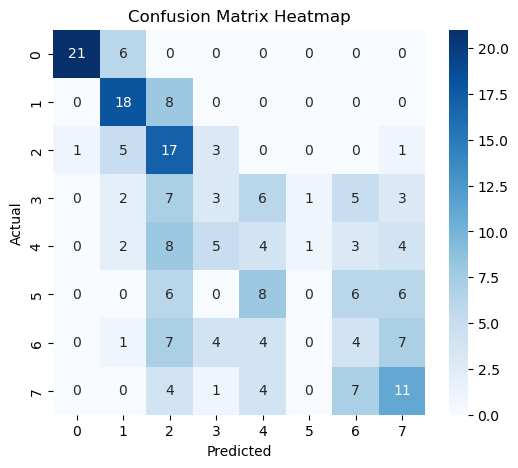

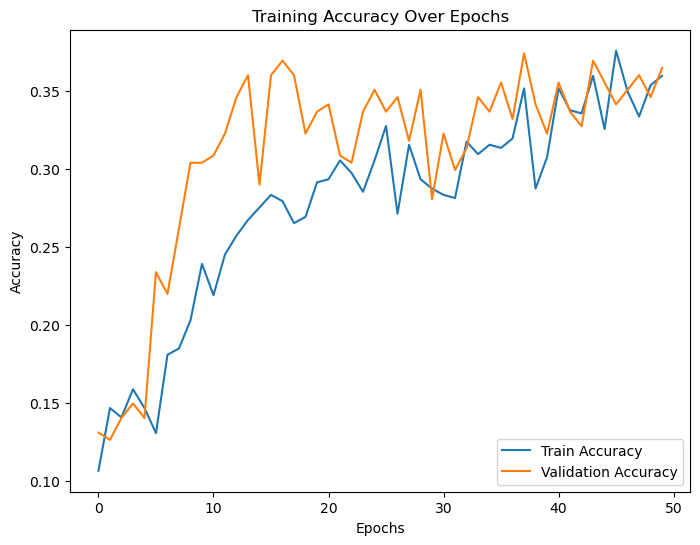

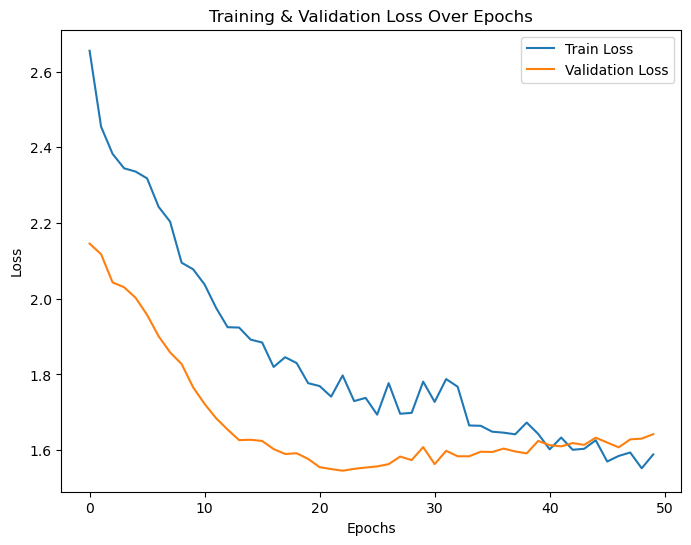

In [52]:
#Best: 0.3 test size, 50 epochs, batch size 32
# Define dataset parameters
num_groups = 8  
group_size = 89  
num_features = 70  

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Create group IDs (0-7, each repeated 70 times)
group_labels = np.repeat(np.arange(num_groups), group_size)  

# Split data while preserving group structure
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X, y, group_labels, test_size=0.3, random_state=42, stratify=group_labels
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to categorical (one-hot encoding)
y_train_categorical = keras.utils.to_categorical(y_train, len(np.unique(y)))
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=8)


# Build ANN model
model = Sequential([
    Dense(128, activation='sigmoid', input_shape=(num_features,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='softmax')  # 8 output classes
])

#.425 = .35 acc
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train_categorical, epochs=50, batch_size=32, validation_data=(X_test, y_test_categorical))

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(8), yticklabels=range(8))
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot training history (Accuracy)
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy Over Epochs')
plt.show()

# Plot training history (Loss)
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss Over Epochs')
plt.show()


### ANN with Early Stopping

Epoch 1/50


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1063 - loss: 2.7501 - val_accuracy: 0.1071 - val_loss: 2.2393
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1325 - loss: 2.4728 - val_accuracy: 0.1071 - val_loss: 2.1689
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1083 - loss: 2.5029 - val_accuracy: 0.1250 - val_loss: 2.1563
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1201 - loss: 2.5215 - val_accuracy: 0.1250 - val_loss: 2.1289
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1167 - loss: 2.4292 - val_accuracy: 0.1250 - val_loss: 2.1112
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1331 - loss: 2.4386 - val_accuracy: 0.1369 - val_loss: 2.0752
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1896 - loss: 2.2856 - val_accuracy: 0.1786 - val_loss: 2.0044
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1982 - loss: 2.2411 - val_accuracy: 0.2202 - val_loss: 1.

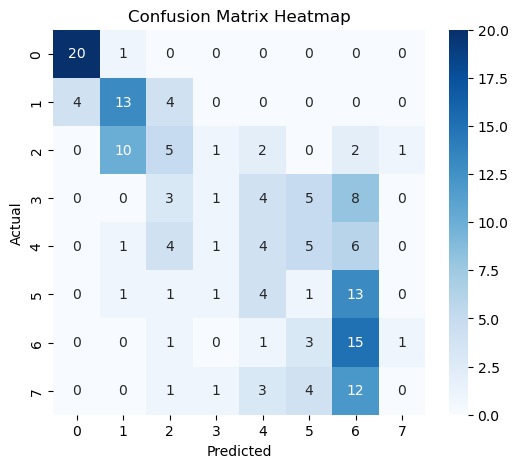

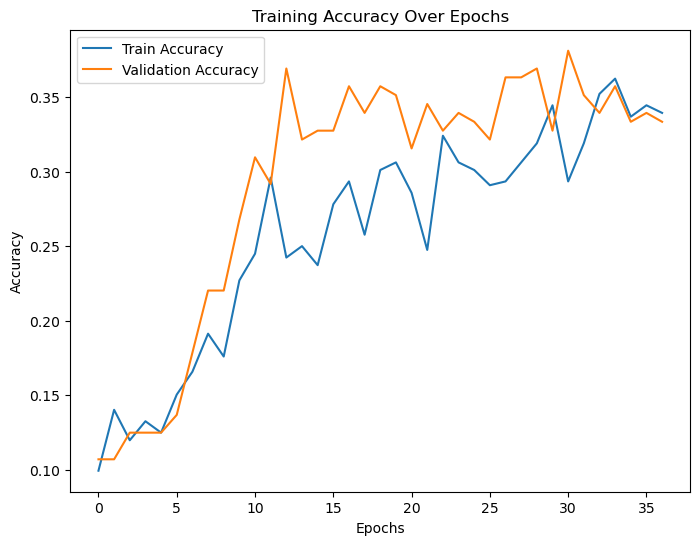

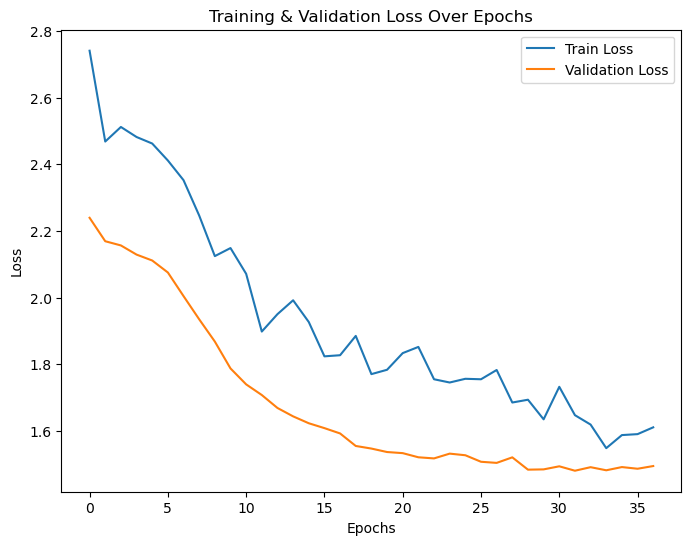

In [19]:
#Best: 0.3 test size, 50 epochs, batch size 32
# Define dataset parameters
num_groups = 8  
group_size = 70  
num_features = 89  

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Create group IDs (0-7, each repeated 70 times)
group_labels = np.repeat(np.arange(num_groups), group_size)  

# Split data while preserving group structure
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X, y, group_labels, test_size=0.3, random_state=42, stratify=group_labels
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to categorical (one-hot encoding)
y_train_categorical = keras.utils.to_categorical(y_train, len(np.unique(y)))
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=8)


# Build ANN model
model = Sequential([
    Dense(128, activation='sigmoid', input_shape=(num_features,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='softmax')  # 8 output classes
])


# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',       # what to monitor
    patience=5,               # how many epochs to wait after last improvement
    restore_best_weights=True # restore model weights from the best epoch
)

#.425 = .35 acc
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


# Train the model with early stopping
history = model.fit(X_train, y_train_categorical,epochs=50,batch_size=32,validation_data=(X_test, y_test_categorical),callbacks=[early_stop])

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(8), yticklabels=range(8))
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot training history (Accuracy)
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy Over Epochs')
plt.show()

# Plot training history (Loss)
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss Over Epochs')
plt.show()


### Running CNN

Epoch 1/50


/Users/abbie/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.1100 - loss: 10.2610 - val_accuracy: 0.1742 - val_loss: 5.2948
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1442 - loss: 8.5218 - val_accuracy: 0.2640 - val_loss: 5.1453
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1930 - loss: 7.9106 - val_accuracy: 0.2472 - val_loss: 5.0041
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2278 - loss: 7.3605 - val_accuracy: 0.2360 - val_loss: 4.8703
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1832 - loss: 7.3444 - val_accuracy: 0.2303 - val_loss: 4.7528
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2100 - loss: 7.1989 - val_accuracy: 0.2247 - val_loss: 4.6379
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2293 - loss: 6.3847 - val_accuracy: 0.2191 - val_loss: 4.5035
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2433 - loss: 6.1105 - val_accuracy: 0.2360 - val_loss: 4

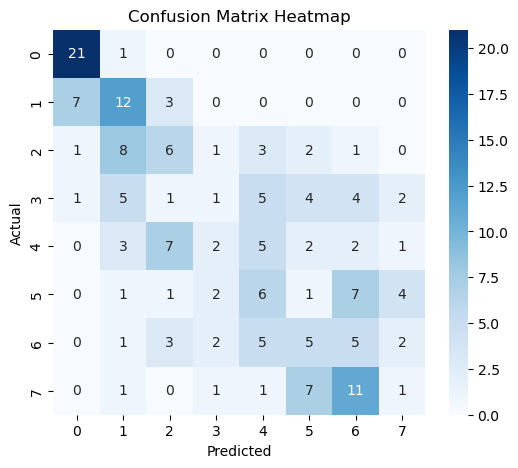

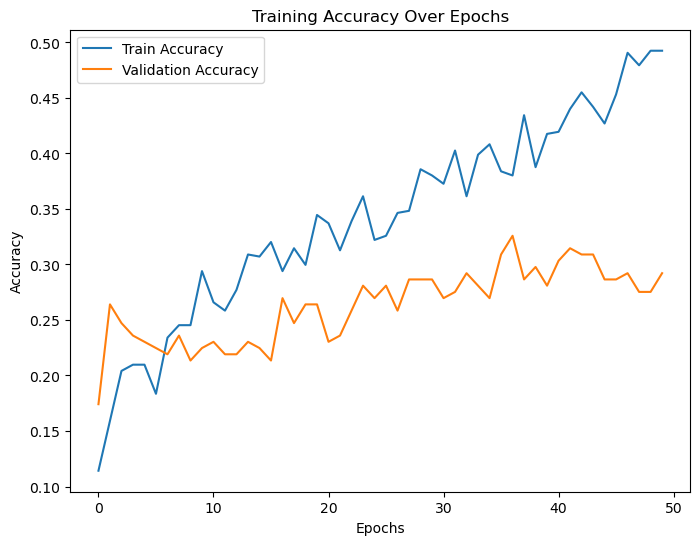

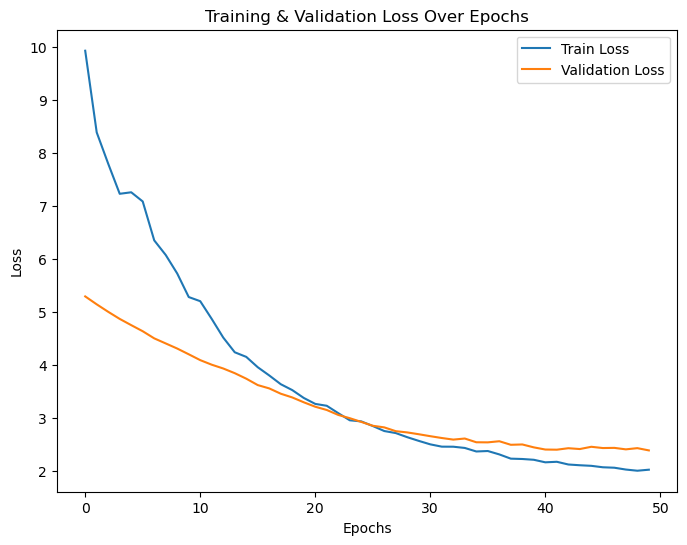

In [40]:
from tensorflow.keras import layers, regularizers
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import StratifiedShuffleSplit
from tensorflow.keras.utils import to_categorical


num_groups = 8  
group_size = 70  
num_features = 89  

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Create group IDs (0-7, each repeated 70 times)
group_labels = np.repeat(np.arange(num_groups), group_size)  

# Split data while preserving group structure
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X, y, group_labels, test_size=0.25, random_state=42, stratify=group_labels
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to categorical (one-hot encoding)
y_train_categorical = keras.utils.to_categorical(y_train, len(np.unique(y)))
y_test_categorical = keras.utils.to_categorical(y_test, num_classes=8)



# Build CNN model
model = Sequential([
    Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(num_features, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(num_groups, activation='softmax')  # 8 output classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train_categorical, epochs=50, batch_size=32, validation_data=(X_test, y_test_categorical))

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

# Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_groups), yticklabels=range(num_groups))
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot training history (Accuracy)
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy Over Epochs')
plt.show()

# Plot training history (Loss)
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss Over Epochs')
plt.show()


### Running the SVM

In [34]:
num_groups = 8  
group_size = 70  
num_features = 89  


# Create group IDs (0-7, each repeated 70 times)
group_labels = np.repeat(np.arange(num_groups), group_size)  

# Step 2: Split while preserving group structure
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X, y, group_labels, test_size=0.6, random_state=42, stratify=group_labels
)

# Convert to DataFrame (optional for checking)
train_df = pd.DataFrame(X_train)
train_df['Label'] = y_train  # Add labels back
train_df['Group'] = group_train  # Keep group IDs

test_df = pd.DataFrame(X_test)
test_df['Label'] = y_test
test_df['Group'] = group_test

# Output check
print("Training Set Size:", X_train.shape, "| Test Set Size:", X_test.shape)
print("Group Distribution in Training:", train_df['Group'].value_counts().to_dict())
print("Group Distribution in Test:", test_df['Group'].value_counts().to_dict())


Training Set Size: (420, 89) | Test Set Size: (140, 89)
Group Distribution in Training: {0: 53, 7: 53, 5: 53, 1: 53, 3: 52, 2: 52, 4: 52, 6: 52}
Group Distribution in Test: {2: 18, 6: 18, 3: 18, 4: 18, 1: 17, 7: 17, 0: 17, 5: 17}


Accuracy: 0.26
Confusion Matrix:
 [[32 10  0  0  0  0  0  0]
 [ 8 20  7  5  2  0  0  0]
 [ 1  9  6 12  5  5  2  2]
 [ 0  1 11  8  8  5  3  6]
 [ 0  1  9 10  5  5  4  8]
 [ 0  1  5 10  6  7  4  9]
 [ 0  0  5  9  6  4  6 12]
 [ 0  0  6 11 11  3  6  5]]
Classification Report:
               precision    recall  f1-score   support

           5       0.78      0.76      0.77        42
          10       0.48      0.48      0.48        42
          15       0.12      0.14      0.13        42
          20       0.12      0.19      0.15        42
          25       0.12      0.12      0.12        42
          30       0.24      0.17      0.20        42
          35       0.24      0.14      0.18        42
          40       0.12      0.12      0.12        42

    accuracy                           0.26       336
   macro avg       0.28      0.26      0.27       336
weighted avg       0.28      0.26      0.27       336



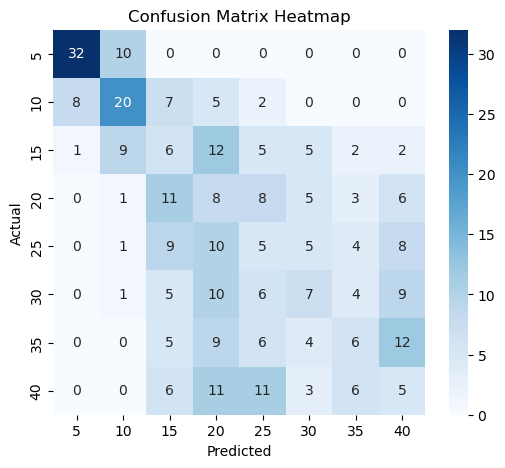

/var/folders/dn/0w_yzqj14dv_khypjlnffyp80000gp/T/ipykernel_58490/2312840514.py:29: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test[:,0], X_test[:,1], c=y_pred, cmap='coolwarm', edgecolors='k', marker='x', alpha=0.6, label='Predicted')


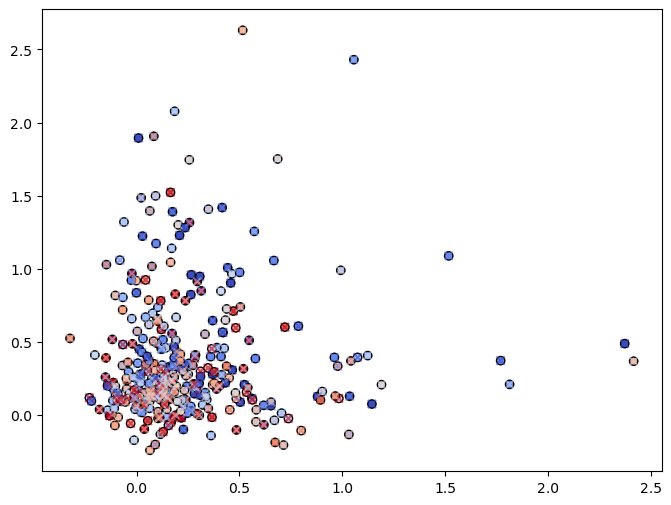

In [41]:
#Training the model
svm_model = SVC(kernel='linear', C=1.0)
#svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

#Prediction
y_pred = svm_model.predict(X_test)

#Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

#Plot Confusion Matrix as Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['5', '10','15','20','25','30','35','40'], yticklabels=['5', '10','15','20','25','30','35','40'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#Plot points
plt.figure(figsize=(8,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='coolwarm', edgecolors='k', marker='o', label='Actual')
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred, cmap='coolwarm', edgecolors='k', marker='x', alpha=0.6, label='Predicted')



In [34]:
len(y_train)

207

In [35]:
y_train[0]

np.int64(20)

In [39]:
count = 0
for i in range(207):
    if y_train[i] == 10:
        count = count+1
print(count)

26
